In [22]:
import os
import librosa
import numpy as np
import pandas as pd
import pickle
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

In [8]:
audio_dir = 'train/'
df = pd.read_csv('train.csv')

## Извлекаем признаки:

In [6]:
feature_params = {
    'n_mels': 128,
    'n_fft': 2048,
    'hop_length': 512,
    'fmin': 0,
    'fmax': None,
    'stats': ('mean', 'std', 'min', 'max'),
    'power': 2.0
}

In [5]:
def extract_mel_features(
    file_path,
    n_mels=128,
    n_fft=2048,
    hop_length=512,
    fmin=0,
    fmax=None,
    stats=('mean', 'std', 'min', 'max'),
    power=2.0
):
    try:
        y, sr = librosa.load(file_path, sr=None)

        mel_spec = librosa.feature.melspectrogram(
            y=y,
            sr=sr,
            n_fft=n_fft,
            hop_length=hop_length,
            n_mels=n_mels,
            fmin=fmin,
            fmax=fmax,
            power=power
        )

        mel_spec = librosa.power_to_db(mel_spec, ref=np.max)

        stat_map = {
            'mean': np.mean(mel_spec, axis=1),
            'std': np.std(mel_spec, axis=1),
            'min': np.min(mel_spec, axis=1),
            'max': np.max(mel_spec, axis=1),
            'median': np.median(mel_spec, axis=1)
        }

        features = np.concatenate([stat_map[s] for s in stats])
        return features

    except Exception as e:
        print(f'Ошибка при обработке {file_path}: {e}')
        return None

In [9]:
X = []
y_labels = []

filename_col = 'file' if 'file' in df.columns else 'filename' 
if filename_col not in df.columns and 'fname' in df.columns:
    filename_col = 'fname'

for index, row in tqdm(df.iterrows(), total=df.shape[0], desc="Processing Audio"):
    file_path = os.path.join(audio_dir, row[filename_col])
    
    features = extract_mel_features(file_path, **feature_params)
    
    if features is not None:
        X.append(features)
        y_labels.append(row['label'])

X = np.array(X)
y = np.array(y_labels)

print(f"Извлечено признаков: X={X.shape}, y={y.shape}")

Processing Audio:   0%|          | 0/5683 [00:00<?, ?it/s]

Извлечено признаков: X=(5683, 512), y=(5683,)


In [ ]:
save_path = 'extracted_features_mel.pkl'

data_to_save = {
    'X': X,
    'y': y,
    'feature_params': feature_params 
}
save_path = 'extracted_features_mel.pkl'

with open(save_path, 'wb') as file:
    pickle.dump(data_to_save, file)

print("Данные успешно сохранены.")

## Реализуем классификатор, вспомогательные функции для построения графиков:

In [23]:
def run_experiment(X, y, model=None, model_name=None, param_grid=None,
                   tune_hyperparams=False, test_size=0.2, random_state=42,
                   scale_data=True, top_n_errors=15):

    X = np.array(X)
    y = np.array(y)
 
    if model is None:
        model = RandomForestClassifier(random_state=random_state, n_jobs=-1)
        if model_name is None:
            model_name = "Random Forest"
    elif model_name is None:
        model_name = type(model).__name__
 
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)
    class_names = label_encoder.classes_
 
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=test_size,
        random_state=random_state, stratify=y_encoded
    )
 
    scaler = None
    if scale_data:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
 
    if tune_hyperparams:
        if param_grid is None:
            param_grid = {
                'n_estimators':     [200, 300],
                'max_depth':        [8, 12, 16, 20],
                'min_samples_split':[6, 12, 20],
                'min_samples_leaf': [2, 4, 8],
                'max_features':     ['sqrt', 'log2'],
                'class_weight':     ['balanced', 'balanced_subsample']
            }
 
        print(f"[{model_name}] Подбор гиперпараметров...")
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
        grid_search = RandomizedSearchCV(
            estimator=model,
            param_distributions=param_grid,
            n_iter=80,
            cv=cv,
            scoring='f1_macro',
            n_jobs=-1,
            random_state=random_state,
            verbose=2
        )
        grid_search.fit(X_train, y_train)
        print(f"[{model_name}] Лучшие параметры: {grid_search.best_params_}")
        model = grid_search.best_estimator_
    else:
        print(f"[{model_name}] Обучение модели...")
        model.fit(X_train, y_train)
 
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
 
    metrics = {}
    for split_name, y_true, y_pred in [("train", y_train, y_pred_train),
                                        ("test", y_test, y_pred_test)]:
        metrics[split_name] = {
            'accuracy': accuracy_score(y_true, y_pred),
            'f1_weighted': f1_score(y_true, y_pred, average='weighted'),
            'f1_macro': f1_score(y_true, y_pred, average='macro'),
        }
 
    print(f"  [{model_name}] Результаты")
    print(f"{'Метрика':<18} {'Train':>8} {'Test':>8} {'Разница':>8}")
    print(f"{'-'*50}")
    for metric_key in ['accuracy', 'f1_weighted', 'f1_macro']:
        tr = metrics['train'][metric_key]
        te = metrics['test'][metric_key]
        diff = tr - te
        print(f"{metric_key:<18} {tr:>8.3f} {te:>8.3f} {diff:>+8.3f}")
    print(f"{'-'*50}")

 
    print(f"\nДетальный отчёт (test):")
    print(classification_report(
        y_test, y_pred_test,
        target_names=[str(c) for c in class_names]
    ))
 
    _plot_analysis(y_test, y_pred_test, class_names, model_name, top_n_errors)
 
    return {
        'model_name': model_name,
        'metrics_train': metrics['train'],
        'metrics_test': metrics['test'],
        'best_model': model,
        'label_encoder': label_encoder,
        'scaler': scaler,
        'y_pred': y_pred_test,
        'y_test': y_test,
    }

In [20]:
def _plot_analysis(y_test, y_pred, class_names, model_name, top_n=15):
 
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(
        y_test, y_pred,
        target_names=[str(c) for c in class_names],
        output_dict=True
    )
    n = len(class_names)
 
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig1, ax1 = plt.subplots(figsize=(max(10, n * 0.35), max(8, n * 0.32)))
    sns.heatmap(
        cm_norm, annot=False, cmap='Blues', ax=ax1,
        xticklabels=class_names, yticklabels=class_names,
        vmin=0, vmax=1, cbar_kws={'label': 'Recall'}
    )
    ax1.set_title(f"Матрица ошибок: {model_name}", fontsize=14)
    ax1.set_xlabel("Предсказано", fontsize=12)
    ax1.set_ylabel("Истинный класс", fontsize=12)
    ax1.tick_params(axis='x', rotation=90, labelsize=9)
    ax1.tick_params(axis='y', rotation=0, labelsize=9)
    plt.tight_layout()
    plt.show()
 
    cm_errors = cm.copy()
    np.fill_diagonal(cm_errors, 0)
    pairs = [
        (cm_errors[i, j], class_names[i], class_names[j])
        for i in range(n) for j in range(n)
        if cm_errors[i, j] > 0
    ]
    pairs.sort(reverse=True)
    top = pairs[:top_n]
 
    if top:
        labels = [f"{t} → {p}" for _, t, p in top]
        values = [v for v, _, _ in top]
        fig2, ax2 = plt.subplots(figsize=(9, max(5, top_n * 0.45)))
        bars = ax2.barh(labels[::-1], values[::-1], color='#e07b54', height=0.6)
        ax2.bar_label(bars, padding=4, fontsize=10)
        ax2.set_title(f"Топ-{top_n} ошибок: {model_name}", fontsize=14)
        ax2.set_xlabel("Количество ошибок", fontsize=12)
        ax2.set_xlim(0, max(values) * 1.15)
        plt.tight_layout()
        plt.show()
 
    f1_scores = {str(c): report[str(c)]['f1-score'] for c in class_names}
    sorted_classes = sorted(f1_scores, key=f1_scores.get)
    sorted_f1 = [f1_scores[c] for c in sorted_classes]
 
    colors = []
    for v in sorted_f1:
        if v < 0.35:
            colors.append('#d73027')
        elif v < 0.55:
            colors.append('#fc8d59')
        elif v < 0.70:
            colors.append('#fee08b')
        else:
            colors.append('#66bd63')
 
    fig3, ax3 = plt.subplots(figsize=(9, max(6, n * 0.30)))
    bars = ax3.barh(sorted_classes, sorted_f1, color=colors, height=0.7)
    ax3.axvline(x=0.5, color='gray', linestyle='--', alpha=0.4, label='F1 = 0.5')
    ax3.bar_label(bars, fmt='%.2f', padding=4, fontsize=9)
    ax3.set_title(f"F1-score по классам: {model_name}", fontsize=14)
    ax3.set_xlabel("F1-score", fontsize=12)
    ax3.set_xlim(0, 1.1)
    ax3.tick_params(axis='y', labelsize=10)
    ax3.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

In [25]:
def plot_f1_comparison(results_base, results_tuned):
    from sklearn.metrics import classification_report

    def get_f1(results):
        report = classification_report(
            results['y_test'], results['y_pred'],
            target_names=[str(c) for c in results['label_encoder'].classes_],
            output_dict=True
        )
        return {c: report[c]['f1-score'] 
                for c in results['label_encoder'].classes_}

    f1_base  = get_f1(results_base)
    f1_tuned = get_f1(results_tuned)

    classes = sorted(f1_base, key=f1_base.get)
    x = np.arange(len(classes))
    w = 0.4

    fig, ax = plt.subplots(figsize=(10, len(classes) * 0.28))
    ax.barh(x - w/2, [f1_base[c]  for c in classes], w, label='RF Base',  color='#7db4d8')
    ax.barh(x + w/2, [f1_tuned[c] for c in classes], w, label='RF Tuned', color='#e07b54')
    ax.set_yticks(x)
    ax.set_yticklabels(classes, fontsize=9)
    ax.axvline(0.5, color='gray', linestyle='--', alpha=0.4)
    ax.set_xlabel('F1-score')
    ax.set_title('Base vs Tuned: F1 по классам')
    ax.legend()
    plt.tight_layout()
    plt.show()

## Обучение Base_model

[RF Base] Обучение модели...
  [RF Base] Результаты
Метрика               Train     Test  Разница
--------------------------------------------------
accuracy              1.000    0.580   +0.420
f1_weighted           1.000    0.567   +0.433
f1_macro              1.000    0.553   +0.447
--------------------------------------------------

Детальный отчёт (test):
                       precision    recall  f1-score   support

      Acoustic_guitar       0.76      0.84      0.79        37
             Applause       0.63      0.86      0.73        37
                 Bark       0.53      0.59      0.56        29
            Bass_drum       0.57      0.69      0.62        36
Burping_or_eructation       0.61      0.48      0.54        23
                  Bus       0.39      0.54      0.45        13
                Cello       0.74      0.70      0.72        37
                Chime       0.64      0.56      0.60        16
             Clarinet       0.85      0.83      0.84        35
    Co

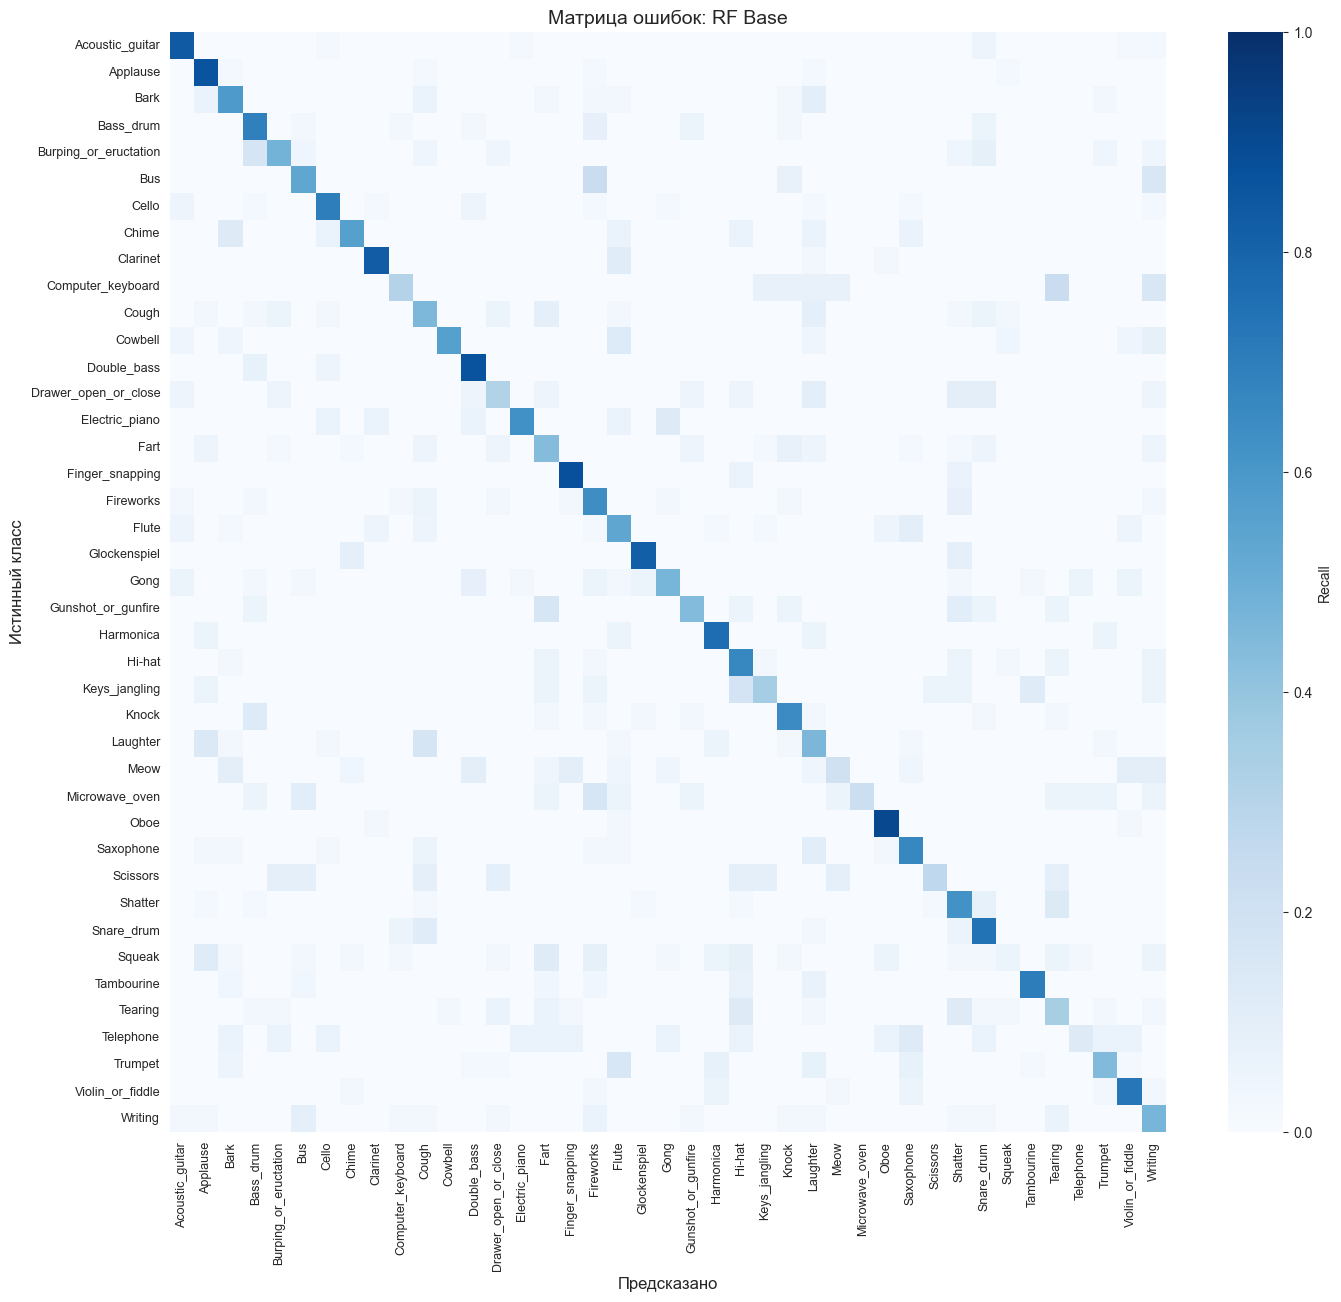

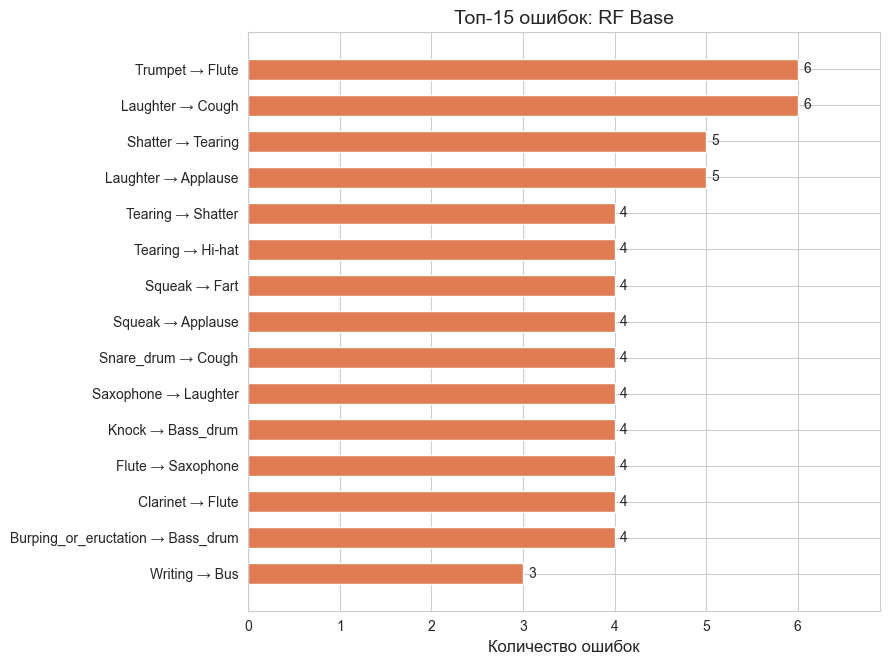

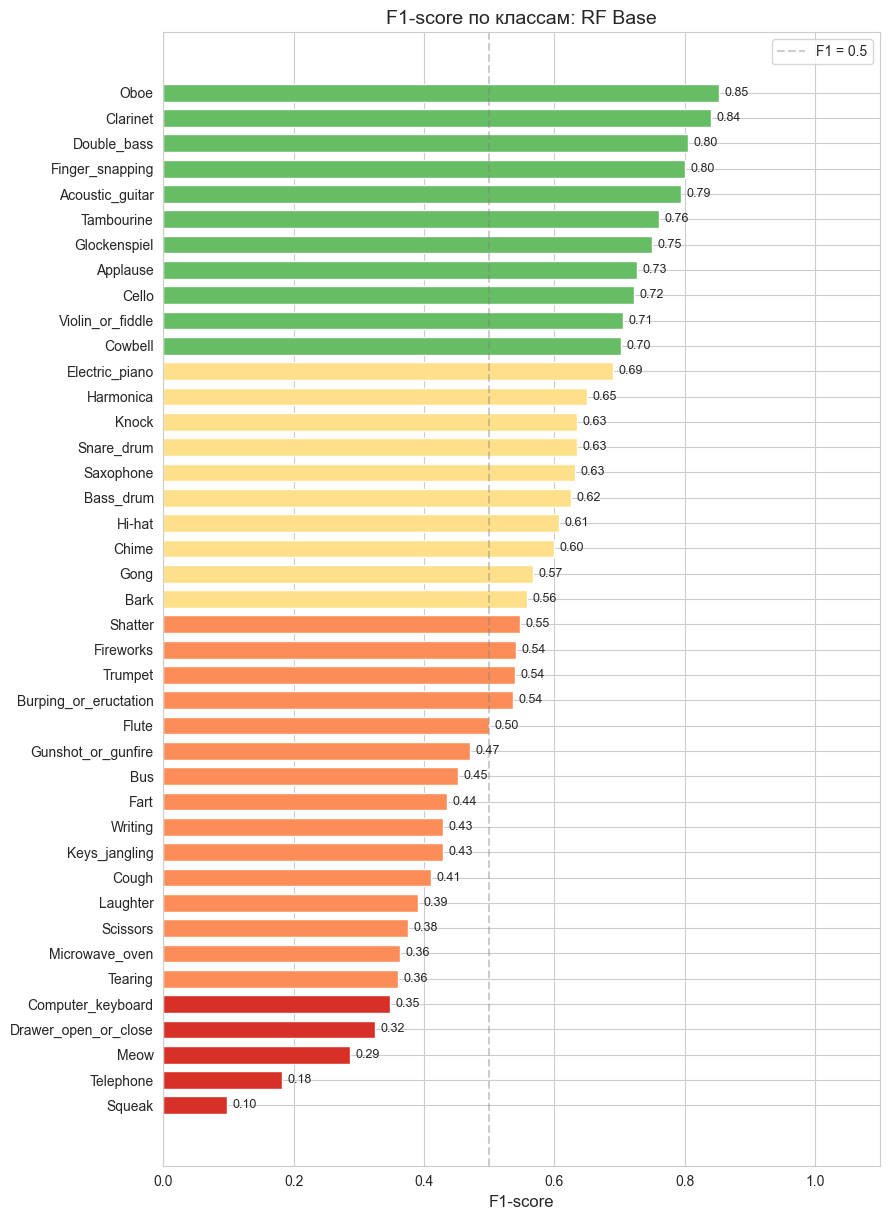

In [21]:
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')
results_base = run_experiment(
    X=X,
    y=y,
    model=rf_base,
    model_name="RF Base",
    tune_hyperparams=False,
    scale_data=True
)

## Grid_search, обучение tuned_model

[RF Tuned] Подбор гиперпараметров...
Fitting 5 folds for each of 80 candidates, totalling 400 fits
[RF Tuned] Лучшие параметры: {'n_estimators': 300, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20, 'class_weight': 'balanced_subsample'}
  [RF Tuned] Результаты
Метрика               Train     Test  Разница
--------------------------------------------------
accuracy              0.998    0.586   +0.412
f1_weighted           0.998    0.575   +0.424
f1_macro              0.998    0.563   +0.436
--------------------------------------------------

Детальный отчёт (test):
                       precision    recall  f1-score   support

      Acoustic_guitar       0.78      0.76      0.77        37
             Applause       0.63      0.84      0.72        37
                 Bark       0.59      0.55      0.57        29
            Bass_drum       0.61      0.69      0.65        36
Burping_or_eructation       0.67      0.61      0.64        23
          

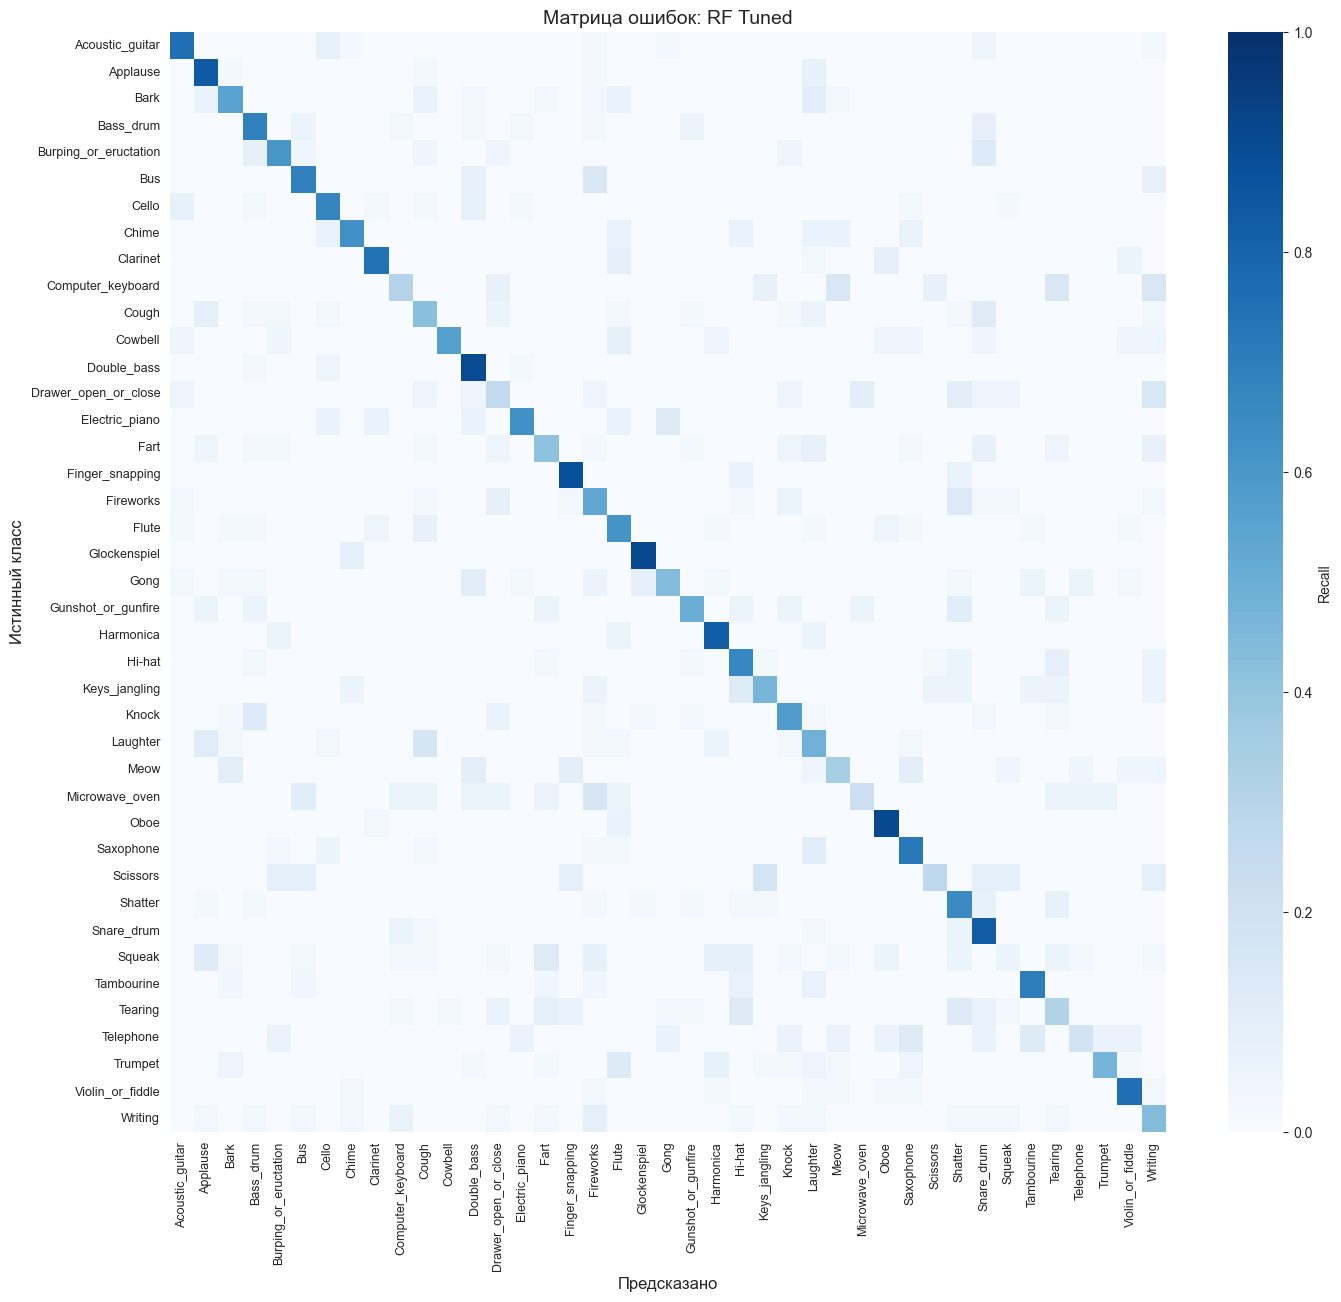

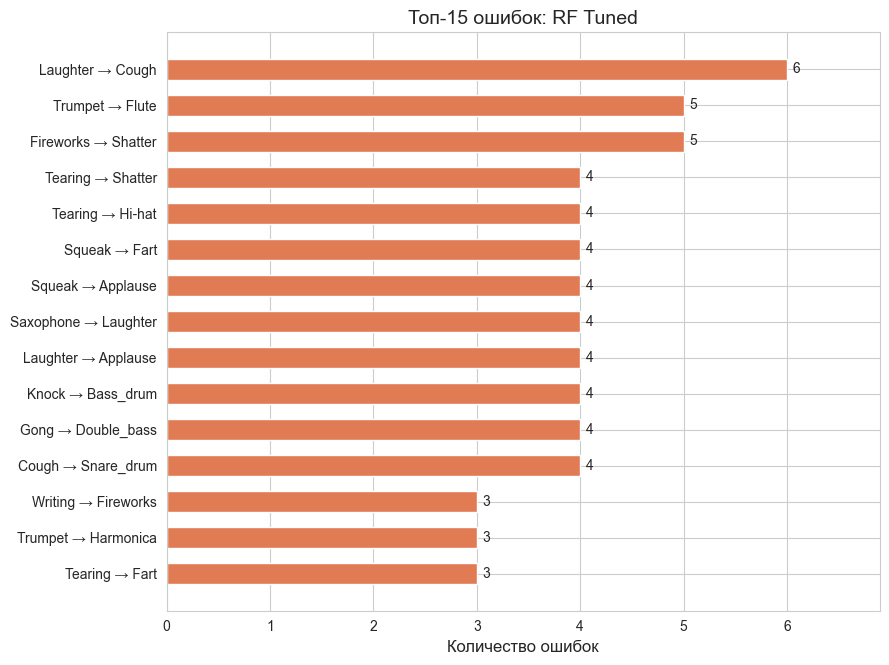

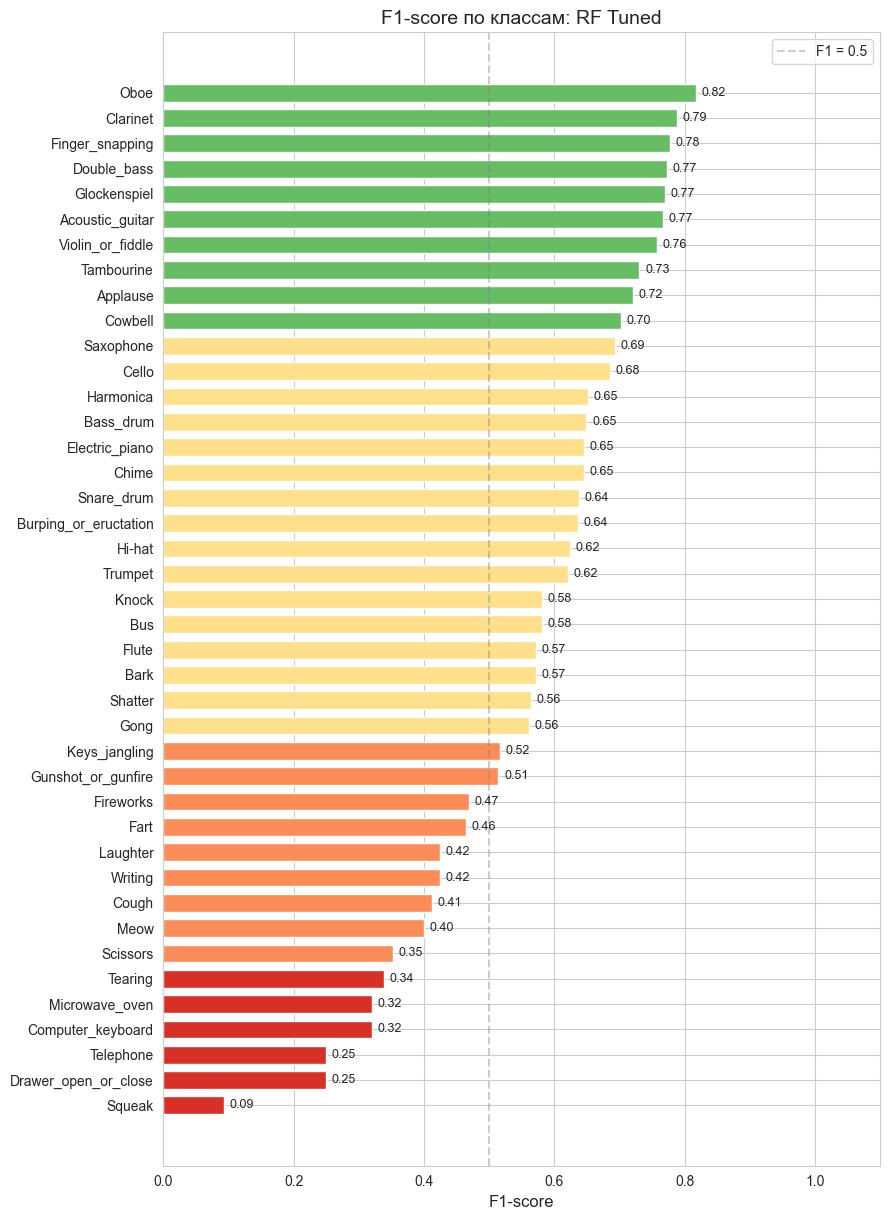

In [24]:
rf_for_tuning = RandomForestClassifier(random_state=42, n_jobs=-1)
results_tuned = run_experiment(
    X=X,
    y=y,
    model=rf_for_tuning,
    model_name="RF Tuned",
    tune_hyperparams=True,
    scale_data=True
)

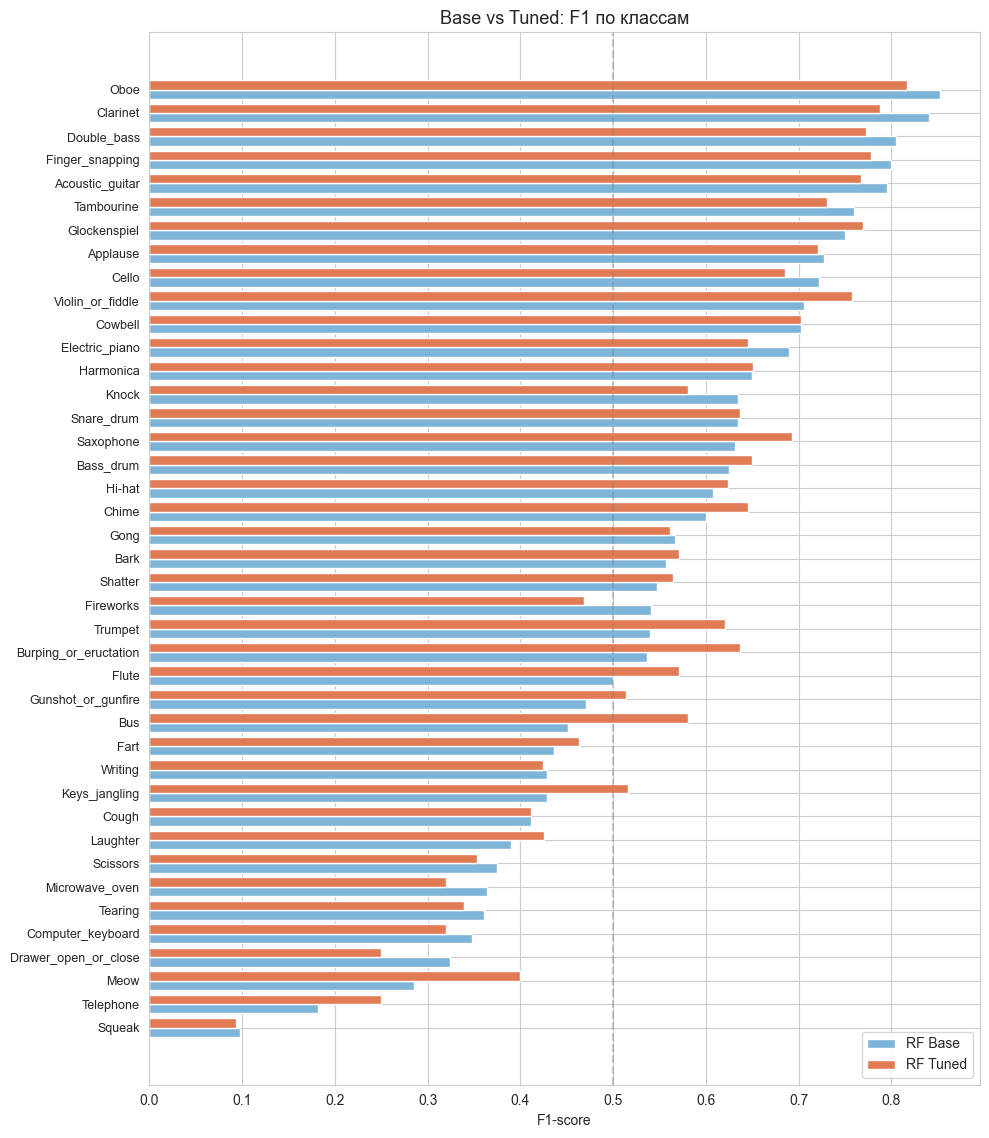

In [26]:
plot_f1_comparison(results_base, results_tuned)

# Выводы:

1. Тюнинг дал скромный прирост. Это говорит о том, что узкое место не в гиперпараметрах, а в самих признаках.

2. Музыкальные инструменты с выраженным спектральным профилем устойчиво дают F1 > 0.70 в обеих моделях. Мел-спектрограмма хорошо кодирует тембр периодических звуков.

3. Духовые инструменты путаются между собой, то же самое происходит с человеческими звуками.

4. Структорно слабые классы: squeak - короткий и непостоянный, telephone - похож на другие, meow - переменная интонация.